In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
from dotenv import load_dotenv
import os
import numpy as np


# Load environment variables from .env
load_dotenv()
# Read the API key from the environment
api_key = os.getenv("fred_api_key")
if not api_key:
    raise ValueError("FRED_API_KEY not found in .env file")
fred = Fred(api_key=api_key)
# Set a unified start date for our training data
start_date = '2015-01-01'
print("FRED API Initialized Successfully.")

FRED API Initialized Successfully.


In [4]:
print("Fetching standard features (CPI, Wages, JOLTS)...")
# 1. Fetch Core Macro Features
cpi = fred.get_series('CPIAUCSL', observation_start=start_date)
cpi.name = 'CPI_All_Urban'

wages = fred.get_series('CES0500000003', observation_start=start_date)
wages.name = 'Nominal_Hourly_Wages'

jolts = fred.get_series('JTSJOL', observation_start=start_date)
jolts.name = 'JOLTS_Openings_Thousands'

print("Fetching archival revision data (Target Variable)...")
# 2. Fetch The Target Variable (Revisions) using ALFRED
# Initial release ("vintage" number reported for that exact month)
payems_initial = fred.get_series_first_release('PAYEMS')
payems_initial = payems_initial.loc[start_date:] 
payems_initial.name = 'PAYEMS_Initial_Release'

# Final release (highly-revised number as it stands today)
payems_final = fred.get_series('PAYEMS', observation_start=start_date)
payems_final.name = 'PAYEMS_Final_Revised'

print("Merging data and engineering core features...")
# 3. Merge into a single DataFrame
df = pd.concat([cpi, wages, jolts, payems_initial, payems_final], axis=1)

# Drop rows where we are missing data across series (e.g., the most recent unresolved month)
df = df.dropna()

# 4. Feature Engineering
# Target Variable (Y)
df['Revision_Delta_Thousands'] = df['PAYEMS_Final_Revised'] - df['PAYEMS_Initial_Release']

# Core Feature (X): Real Hourly Wage (Adjusting nominal wages for inflation)
df['Real_Hourly_Wage'] = (df['Nominal_Hourly_Wages'] / df['CPI_All_Urban']) * 100

# Core Feature (X): The Gap (Year-over-Year % Change in Real Wages)
df['Real_Wage_YoY_Growth'] = df['Real_Hourly_Wage'].pct_change(periods=12) * 100

print("DataFrame 'df' built successfully! Here is a preview:")
display(df.tail())

Fetching standard features (CPI, Wages, JOLTS)...
Fetching archival revision data (Target Variable)...
Merging data and engineering core features...
DataFrame 'df' built successfully! Here is a preview:


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/indexes/base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,CPI_All_Urban,Nominal_Hourly_Wages,JOLTS_Openings_Thousands,PAYEMS_Initial_Release,PAYEMS_Final_Revised,Revision_Delta_Thousands,Real_Hourly_Wage,Real_Wage_YoY_Growth
2025-09-01,324.245,36.70,7169.0,159626.0,158548.0,-1078.0,11.318602,0.801532
2025-11-01,325.063,37.00,6846.0,159552.0,158449.0,-1103.0,11.382409,1.315316
2025-12-01,326.031,37.02,6550.0,159526.0,158432.0,-1094.0,11.354748,0.957748
2026-01-01,326.588,37.15,7240.0,158627.0,158592.0,-35.0,11.375188,1.227383
2026-02-01,327.460,37.29,6882.0,158466.0,158459.0,-7.0,11.387650,1.345323


In [7]:
print("Engineering lagged and rolling features...")
# 1. Isolate the Target Variable (y)
y = df['Revision_Delta_Thousands']

# 2. Base Features (X)
X = df[['CPI_All_Urban', 'Nominal_Hourly_Wages', 'JOLTS_Openings_Thousands', 'Real_Wage_YoY_Growth']].copy()

# 3. Create "Economic Memory" Features
# How many job openings were there 1 and 3 months ago?
X['JOLTS_Lag_1M'] = X['JOLTS_Openings_Thousands'].shift(1)
X['JOLTS_Lag_3M'] = X['JOLTS_Openings_Thousands'].shift(3)

# What was the real wage growth trend 3 months ago?
X['Real_Wage_Growth_Lag_3M'] = X['Real_Wage_YoY_Growth'].shift(3)

# 6-Month Rolling Averages to smooth out monthly noise
X['JOLTS_6M_Moving_Avg'] = X['JOLTS_Openings_Thousands'].rolling(window=6).mean()
X['Real_Wage_6M_Moving_Avg'] = X['Real_Wage_YoY_Growth'].rolling(window=6).mean()

# Drop the NaN rows created by the shifting and rolling windows
X = X.dropna()
# Align the target variable index to match the newly trimmed X dataframe
y = y.loc[X.index] 

print("Executing chronological train/test split...")
# 4. Chronological Train/Test Split
# We train on the "normal" era and test if the model can predict the recent massive revisions
split_date = '2023-01-01'

X_train = X.loc[X.index < split_date]
y_train = y.loc[y.index < split_date]

X_test = X.loc[X.index >= split_date]
y_test = y.loc[y.index >= split_date]

print(f"Training Data: {len(X_train)} months | Testing Data: {len(X_test)} months")

Engineering lagged and rolling features...
Executing chronological train/test split...
Training Data: 79 months | Testing Data: 37 months


Updated Training Data: 91 months | Testing Data: 25 months
Training the Random Forest Regressor...

--- Out-of-Time Performance Metrics ---
Mean Absolute Error (MAE): 582 jobs
Root Mean Squared Error (RMSE): 633 jobs

--- Model Feature Importance (What drove the predictions?) ---


,Feature,Importance_Score
7,JOLTS_6M_Moving_Avg,0.325618
5,JOLTS_Lag_3M,0.203012
3,Real_Wage_YoY_Growth,0.193355
2,JOLTS_Openings_Thousands,0.092548
4,JOLTS_Lag_1M,0.047830
1,Nominal_Hourly_Wages,0.040015
6,Real_Wage_Growth_Lag_3M,0.033756
8,Real_Wage_6M_Moving_Avg,0.032478
0,CPI_All_Urban,0.031389


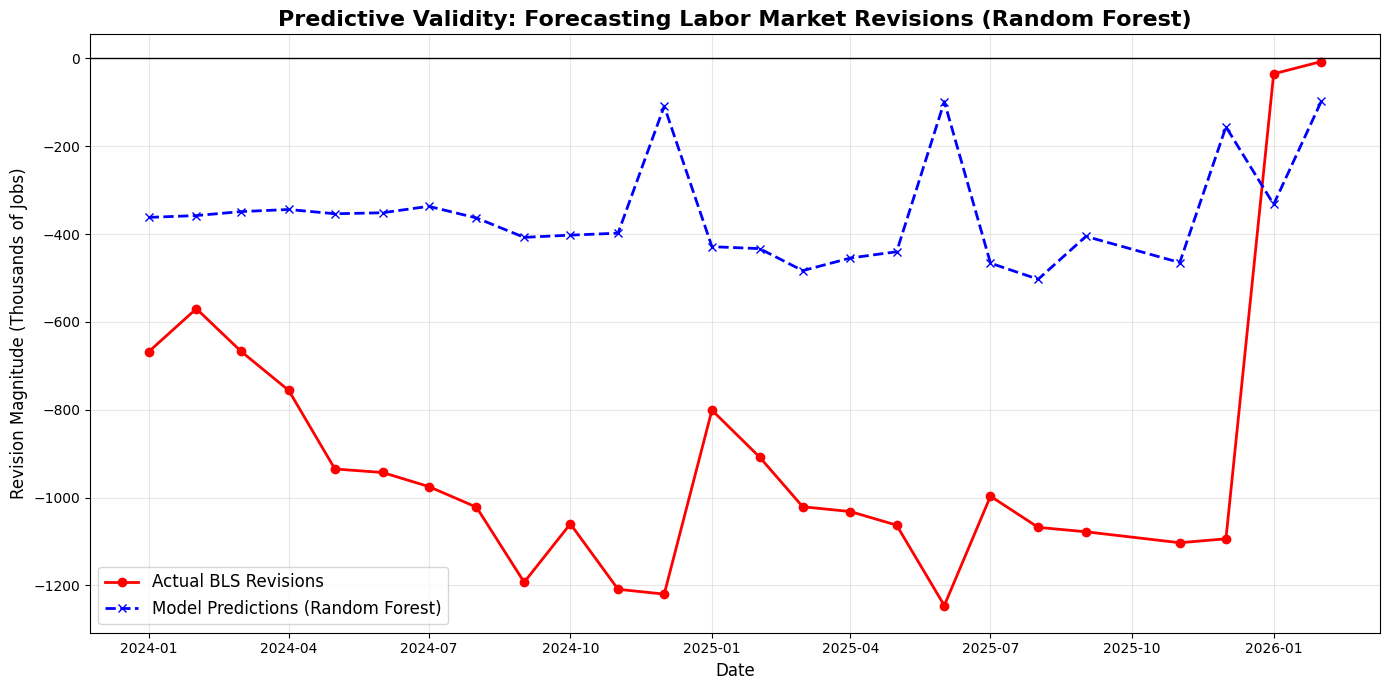

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

# 1. Update the Split Date so the model learns from the 2023 shock
split_date = '2024-01-01'

X_train = X.loc[X.index < split_date]
y_train = y.loc[y.index < split_date]

X_test = X.loc[X.index >= split_date]
y_test = y.loc[y.index >= split_date]

print(f"Updated Training Data: {len(X_train)} months | Testing Data: {len(X_test)} months")

# 2. Train a Random Forest Model (No scaling needed for tree-based models)
print("Training the Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Make Predictions
y_pred = rf_model.predict(X_test)

# 4. Error Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Out-of-Time Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.0f} jobs")
print(f"Root Mean Squared Error (RMSE): {rmse:.0f} jobs\n")

# 5. Extract Feature Importance (Random Forest doesn't use coefficients, it uses importance scores)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Score': rf_model.feature_importances_
}).sort_values(by='Importance_Score', ascending=False)

print("--- Model Feature Importance (What drove the predictions?) ---")
display(importance_df)

# 6. Re-Plot the Predictive Validity
results_df = pd.DataFrame({
    'Actual_Revisions': y_test,
    'Predicted_Revisions': y_pred
}, index=y_test.index)

plt.figure(figsize=(14, 7))
plt.plot(results_df.index, results_df['Actual_Revisions'], color='red', marker='o', label='Actual BLS Revisions', linewidth=2)
plt.plot(results_df.index, results_df['Predicted_Revisions'], color='blue', linestyle='--', marker='x', label='Model Predictions (Random Forest)', linewidth=2)

plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title('Predictive Validity: Forecasting Labor Market Revisions (Random Forest)', fontsize=16, fontweight='bold')
plt.ylabel('Revision Magnitude (Thousands of Jobs)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("Fetching new external macroeconomic features...")

# 1. Fetch S&P 500 (Resampled to monthly start to align with BLS data)
sp500 = fred.get_series('SP500', observation_start=start_date).resample('MS').mean()
sp500.name = 'SP500_Level'

# 2. Fetch  VIX Volatility Index
vix = fred.get_series('VIXCLS', observation_start=start_date).resample('MS').mean()
vix.name = 'VIX_Volatility'

# 3. Fetch Cost of Capital (Federal Funds Rate)
rates = fred.get_series('FEDFUNDS', observation_start=start_date)
rates.name = 'Fed_Funds_Rate'

print("Building df_advanced...")
# Combine existing base series (already in memory) with the new macro series
df_advanced = pd.concat([cpi, wages, jolts, payems_initial, payems_final, sp500, vix, rates], axis=1)

# Drop missing values to align timelines
df_advanced = df_advanced.dropna()

# --- Re-calculate Base Targets & Features ---
df_advanced['Revision_Delta_Thousands'] = df_advanced['PAYEMS_Final_Revised'] - df_advanced['PAYEMS_Initial_Release']
df_advanced['Real_Hourly_Wage'] = (df_advanced['Nominal_Hourly_Wages'] / df_advanced['CPI_All_Urban']) * 100
df_advanced['Real_Wage_YoY_Growth'] = df_advanced['Real_Hourly_Wage'].pct_change(periods=12) * 100

# --- Advanced Feature Engineering (The New Stuff) ---
# Stock Market Momentum: Has the market grown or shrunk over the last 6 months?
df_advanced['SP500_6M_Growth'] = df_advanced['SP500_Level'].pct_change(periods=6) * 100

# Rate Shock: Did interest rates jump significantly in the last 3 months?
df_advanced['Rate_Change_3M'] = df_advanced['Fed_Funds_Rate'].diff(periods=3)

# --- Legacy Lagged Features (from your previous model) ---
df_advanced['JOLTS_Lag_1M'] = df_advanced['JOLTS_Openings_Thousands'].shift(1)
df_advanced['JOLTS_Lag_3M'] = df_advanced['JOLTS_Openings_Thousands'].shift(3)
df_advanced['JOLTS_6M_Moving_Avg'] = df_advanced['JOLTS_Openings_Thousands'].rolling(window=6).mean()
df_advanced['Real_Wage_6M_Moving_Avg'] = df_advanced['Real_Wage_YoY_Growth'].rolling(window=6).mean()
df_advanced['Real_Wage_Growth_Lag_3M'] = df_advanced['Real_Wage_YoY_Growth'].shift(3)

# Drop the NaN rows created by the rolling/shifting functions
df_advanced = df_advanced.dropna()

print("Advanced DataFrame built successfully!")
display(df_advanced.tail())

Fetching new external macroeconomic features...
Building df_advanced...
Advanced DataFrame built successfully!


,CPI_All_Urban,Nominal_Hourly_Wages,JOLTS_Openings_Thousands,PAYEMS_Initial_Release,PAYEMS_Final_Revised,SP500_Level,VIX_Volatility,Fed_Funds_Rate,Revision_Delta_Thousands,Real_Hourly_Wage,Real_Wage_YoY_Growth,SP500_6M_Growth,Rate_Change_3M,JOLTS_Lag_1M,JOLTS_Lag_3M,JOLTS_6M_Moving_Avg,Real_Wage_6M_Moving_Avg,Real_Wage_Growth_Lag_3M
2025-09-01,324.245,36.70,7169.0,159626.0,158548.0,6584.018095,15.789091,4.22,-1078.0,11.318602,0.801532,15.834578,-0.11,6919.0,7204.0,7131.500000,1.210154,1.144899
2025-11-01,325.063,37.00,6846.0,159552.0,158449.0,6740.885789,19.769500,3.88,-1103.0,11.382409,1.315316,25.540389,-0.45,7169.0,7089.0,7089.500000,1.170859,1.187193
2025-12-01,326.031,37.02,6550.0,159526.0,158432.0,6853.025455,15.548182,3.72,-1094.0,11.354748,0.957748,17.933581,-0.61,6846.0,6919.0,6962.833333,1.068921,1.006836
2026-01-01,326.588,37.15,7240.0,158627.0,158592.0,6929.122000,16.179048,3.64,-35.0,11.375188,1.227383,14.911737,-0.58,6550.0,7169.0,6968.833333,1.082668,0.801532
2026-02-01,327.460,37.29,6882.0,158466.0,158459.0,6893.806316,19.207000,3.64,-7.0,11.387650,1.345323,9.486354,-0.24,7240.0,6846.0,6934.333333,1.109023,1.315316


Setting up the Macro-Aware Model...
Training the Advanced Random Forest Regressor...

--- Advanced Model Out-of-Time Performance ---
Mean Absolute Error (MAE): 598 jobs
Root Mean Squared Error (RMSE): 635 jobs

--- Advanced Model Feature Importance ---


,Feature,Importance_Score
6,JOLTS_6M_Moving_Avg,0.336090
3,Real_Wage_YoY_Growth,0.162378
12,Fed_Funds_Rate,0.129280
5,JOLTS_Lag_3M,0.105771
2,JOLTS_Openings_Thousands,0.059162
9,SP500_6M_Growth,0.045822
4,JOLTS_Lag_1M,0.028995
7,Real_Wage_6M_Moving_Avg,0.026780
11,Rate_Change_3M,0.026240
1,Nominal_Hourly_Wages,0.026165


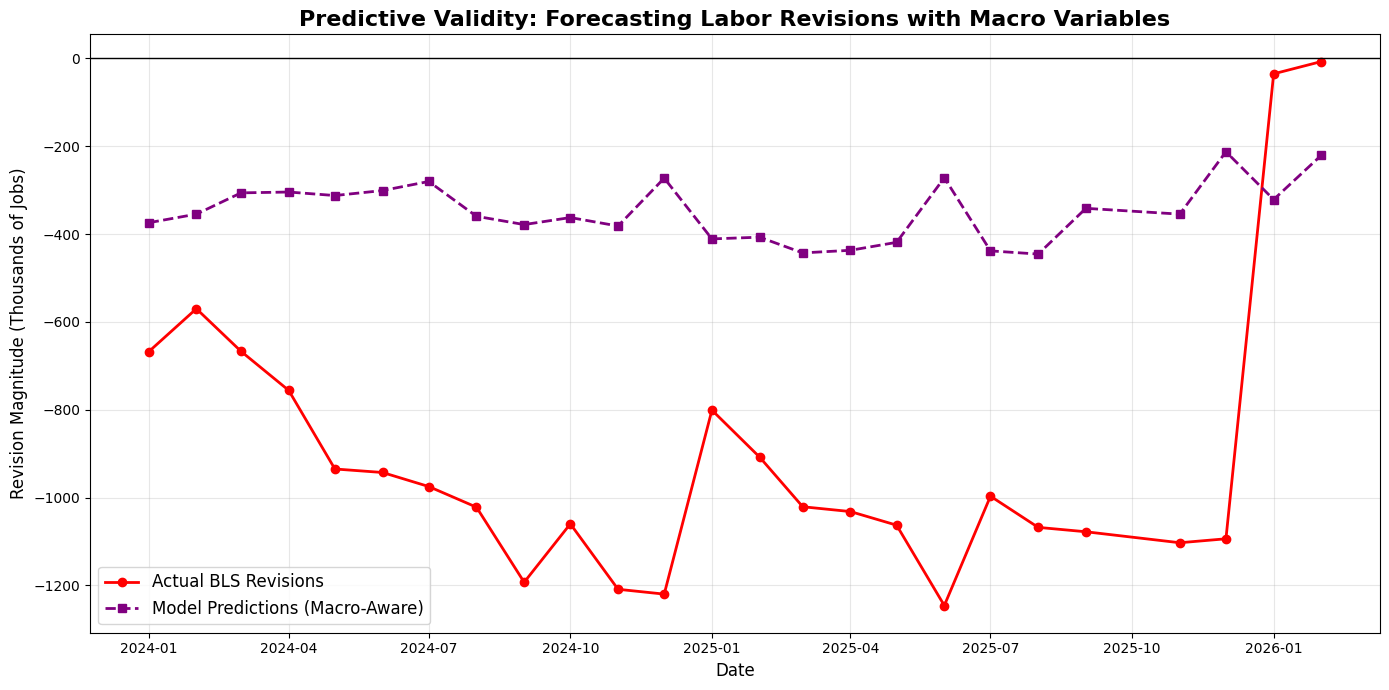

In [13]:
from sklearn.ensemble import RandomForestRegressor

print("Setting up the Macro-Aware Model...")
# 1. Define Target Variable
y_adv = df_advanced['Revision_Delta_Thousands']

# 2. Define Advanced Feature Set (Including our new macro variables)
X_adv = df_advanced[[
    'CPI_All_Urban', 'Nominal_Hourly_Wages', 'JOLTS_Openings_Thousands', 
    'Real_Wage_YoY_Growth', 'JOLTS_Lag_1M', 'JOLTS_Lag_3M', 
    'JOLTS_6M_Moving_Avg', 'Real_Wage_6M_Moving_Avg', 'Real_Wage_Growth_Lag_3M',
    'SP500_6M_Growth', 'VIX_Volatility', 'Rate_Change_3M', 'Fed_Funds_Rate'
]]

# 3. Train/Test Split (Using the successful 2024 cutoff)
split_date = '2024-01-01'

X_train_adv = X_adv.loc[X_adv.index < split_date]
y_train_adv = y_adv.loc[y_adv.index < split_date]

X_test_adv = X_adv.loc[X_adv.index >= split_date]
y_test_adv = y_adv.loc[y_adv.index >= split_date]

# 4. Train the Model
print("Training the Advanced Random Forest Regressor...")
rf_macro = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_macro.fit(X_train_adv, y_train_adv)

# 5. Evaluate and Extract Metrics
y_pred_adv = rf_macro.predict(X_test_adv)
mae_adv = mean_absolute_error(y_test_adv, y_pred_adv)
rmse_adv = np.sqrt(mean_squared_error(y_test_adv, y_pred_adv))

print(f"\n--- Advanced Model Out-of-Time Performance ---")
print(f"Mean Absolute Error (MAE): {mae_adv:.0f} jobs")
print(f"Root Mean Squared Error (RMSE): {rmse_adv:.0f} jobs\n")

# 6. Check the New Feature Hierarchy
importance_adv_df = pd.DataFrame({
    'Feature': X_adv.columns,
    'Importance_Score': rf_macro.feature_importances_
}).sort_values(by='Importance_Score', ascending=False)

print("--- Advanced Model Feature Importance ---")
display(importance_adv_df)

# 7. Plot Actuals vs Predictions for the Presentation
results_adv_df = pd.DataFrame({
    'Actual_Revisions': y_test_adv,
    'Predicted_Revisions': y_pred_adv
}, index=y_test_adv.index)

plt.figure(figsize=(14, 7))
plt.plot(results_adv_df.index, results_adv_df['Actual_Revisions'], color='red', marker='o', label='Actual BLS Revisions', linewidth=2)
plt.plot(results_adv_df.index, results_adv_df['Predicted_Revisions'], color='purple', linestyle='--', marker='s', label='Model Predictions (Macro-Aware)', linewidth=2)

plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title('Predictive Validity: Forecasting Labor Revisions with Macro Variables', fontsize=16, fontweight='bold')
plt.ylabel('Revision Magnitude (Thousands of Jobs)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Calculating SHAP values for the Macro-Aware Random Forest...


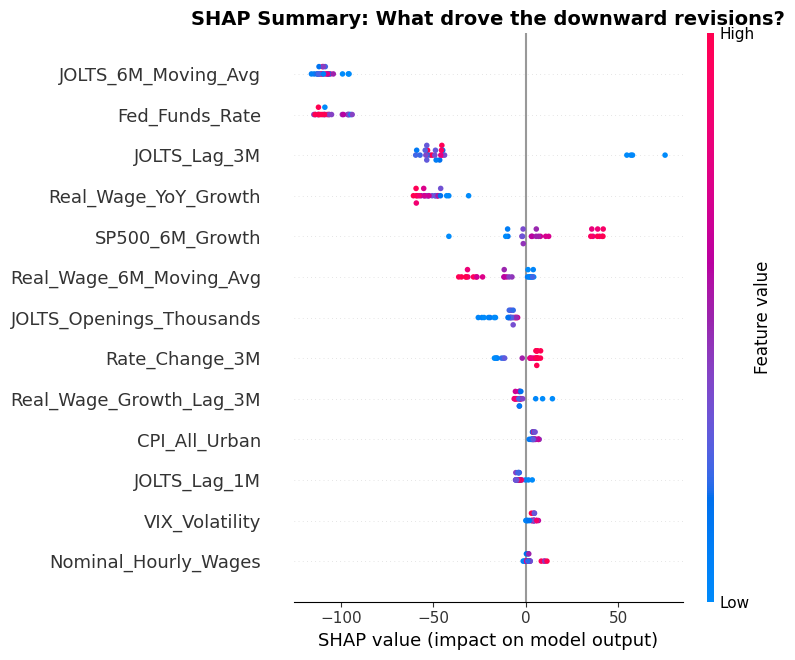

In [14]:
import shap

print("Calculating SHAP values for the Macro-Aware Random Forest...")

# 1. Initialize the SHAP explainer on your trained model
explainer = shap.TreeExplainer(rf_macro)

# 2. Calculate SHAP values for your test set
shap_values = explainer.shap_values(X_test_adv)

# 3. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: What drove the downward revisions?", fontsize=14, fontweight='bold')
# This plot shows the impact of every single data point. 
# Red means a feature's value was high; Blue means it was low.
shap.summary_plot(shap_values, X_test_adv, show=False)
plt.tight_layout()
plt.show()

In [18]:
# Drop missing values to ensure a clean dataset for the regression
df_inference = df_inference.dropna()

print("Cleaning data types for statsmodels...")
# THE FIX: Force all columns to be pure floating-point numbers.
# This prevents the 'numpy dtype of object' error.
df_inference = df_inference.astype(float)

print("Running OLS Regression for Statistical Inference...")

# 5. Define Target and Features for the Academic Model
y_ols = df_inference['Revision_Delta_Thousands']

X_ols = df_inference[[
    'Real_Wage_YoY_Growth', 
    'Fed_Funds_Lag_6M', 
    'Yield_Curve_Spread', 
    'Corporate_Bond_Spread',
    'Consumer_Sentiment',
    'JOLTS_6M_Moving_Avg'
]]

# statsmodels requires us to explicitly add a constant (the y-intercept)
X_ols = sm.add_constant(X_ols)

# 6. Fit the OLS Model
ols_model = sm.OLS(y_ols, X_ols).fit()

# 7. Display the summary table
print("\n--- OLS Regression Results (Inference Model) ---")
print(ols_model.summary())

Cleaning data types for statsmodels...
Running OLS Regression for Statistical Inference...

--- OLS Regression Results (Inference Model) ---
                               OLS Regression Results                               
Dep. Variable:     Revision_Delta_Thousands   R-squared:                       0.492
Model:                                  OLS   Adj. R-squared:                  0.379
Method:                       Least Squares   F-statistic:                     4.363
Date:                      Mon, 20 Apr 2026   Prob (F-statistic):            0.00333
Time:                              13:52:37   Log-Likelihood:                -237.64
No. Observations:                        34   AIC:                             489.3
Df Residuals:                            27   BIC:                             500.0
Df Model:                                 6                                         
Covariance Type:                  nonrobust                                         
         

In [21]:
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import time

print("Building Panel Data Structure by Industry...")

# THE FIX: Corrected the FRED Tickers for Leisure/Hospitality and Manufacturing
industries = {
    'Professional_Services': {'jolts': 'JTS540099JOL', 'payrolls': 'USPBS'},
    'Leisure_Hospitality': {'jolts': 'JTS7000JOL', 'payrolls': 'USLAH'},
    'Manufacturing': {'jolts': 'JTS3000JOL', 'payrolls': 'MANEMP'}
}

panel_data = []

# 2. Fetch data for each entity
for industry_name, tickers in industries.items():
    print(f"Fetching data for: {industry_name}")
    
    try:
        # Fetching directly from the FRED API
        jolts = fred.get_series(tickers['jolts'], observation_start=start_date)
        pay_initial = fred.get_series_first_release(tickers['payrolls']).loc[start_date:]
        pay_final = fred.get_series(tickers['payrolls'], observation_start=start_date)
        
        # Combine into a temporary dataframe
        temp_df = pd.concat([jolts, pay_initial, pay_final], axis=1)
        temp_df.columns = ['JOLTS_Openings', 'PAY_Initial', 'PAY_Final']
        
        # Add the Entity Name column
        temp_df['Industry'] = industry_name
        
        # Calculate the Industry-Specific Target Variable
        temp_df['Revision_Delta'] = temp_df['PAY_Final'] - temp_df['PAY_Initial']
        
        panel_data.append(temp_df)
        time.sleep(1) # Prevent rate limiting
        
    except Exception as e:
        print(f"Failed to fetch {industry_name}: {e}")

# 3. Create the Panel DataFrame
df_panel = pd.concat(panel_data)

# Merge in the Macro Variables (Real Wage and Fed Funds) from df_advanced
df_panel = df_panel.join(df_advanced[['Real_Wage_YoY_Growth', 'Fed_Funds_Rate']], how='inner')

# 4. Set the MultiIndex (CRITICAL STEP FOR PANEL DATA)
# Level 0 = Entity (Industry), Level 1 = Time (Date)
df_panel = df_panel.reset_index().set_index(['Industry', 'index'])
df_panel.index.names = ['Entity', 'Date']
df_panel = df_panel.dropna()

print("\nPanel DataFrame Ready. Preview:")
display(df_panel.head())

print("\nRunning Entity Fixed Effects Panel Regression...")

# 5. Define Model Variables
y_panel = df_panel['Revision_Delta']
X_panel = df_panel[['JOLTS_Openings', 'Real_Wage_YoY_Growth', 'Fed_Funds_Rate']]
X_panel = sm.add_constant(X_panel)

# 6. Fit the Fixed Effects Model
# entity_effects=True isolates the baseline differences between industries
mod = PanelOLS(y_panel, X_panel, entity_effects=True)
res = mod.fit(cov_type='clustered', cluster_entity=True)

print(res.summary)

Building Panel Data Structure by Industry...
Fetching data for: Professional_Services


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/indexes/base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


Fetching data for: Leisure_Hospitality


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/indexes/base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


Fetching data for: Manufacturing


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/indexes/base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)



Panel DataFrame Ready. Preview:


JOLTS_Openings PAY_Initial  PAY_Final  \
Entity                Date                                                
Professional_Services 2017-09-01          1113.0     20807.0    20668.0   
                      2017-10-01          1323.0     20870.0    20709.0   
                      2017-11-01          1034.0     20928.0    20725.0   
                      2017-12-01           971.0     20943.0    20764.0   
                      2018-01-01          1118.0     20694.0    20822.0   

                                 Revision_Delta  Real_Wage_YoY_Growth  \
Entity                Date                                              
Professional_Services 2017-09-01         -139.0              0.600291   
                      2017-10-01         -161.0              0.289985   
                      2017-11-01         -203.0              0.292201   
                      2017-12-01         -179.0              0.557765   
                      2018-01-01          128.0              0.604899   

                                  Fed_Funds_Rate  
Entity                Date                        
Professional_Services 2017-09-01            1.15  
                      2017-10-01            1.15  
                      2017-11-01            1.16  
                      2017-12-01            1.30  
                      2018-01-01            1.41


Running Entity Fixed Effects Panel Regression...
                          PanelOLS Estimation Summary                           
Dep. Variable:         Revision_Delta   R-squared:                        0.1992
Estimator:                   PanelOLS   R-squared (Between):             -0.2679
No. Observations:                 303   R-squared (Within):               0.1992
Date:                Mon, Apr 20 2026   R-squared (Overall):              0.1704
Time:                        13:59:20   Log-likelihood                   -1987.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      24.627
Entities:                           3   P-value                           0.0000
Avg Obs:                       101.00   Distribution:                   F(3,297)
Min Obs:                       101.00                                           
Max Obs:                       101.00   F-statistic (robust